# Rolling Mean and Standard Deviation

## $ \mu _n  = \frac{1}{N} \sum_{\frac{-(N-1)}{2}}^{\frac{N-1}{2}} y_{n+k}$

## $ \sigma _n = \sqrt{\frac{1}{N} \sum_{\frac{-(N-1)}{2}}^{\frac{n-1}{2}} (y_{n+k} - \mu _n)^2} $

In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

In [9]:
def mean_std(audio, window_length= 101):

    if window_length%2 == 0:
        window_length += 1

    half_window = window_length//2
    mean = np.zeros_like(audio)
    std = np.zeros_like(audio)

    # paddind to handle boundries

    padded = np.pad(audio, (half_window, half_window), mode='reflect')

    for i in range(len(audio)):

        window = padded[i:i + window_length]

        mean[i] = np.mean(window)
        std[i] = np.std(window)

    return mean, std

In [10]:
sr = 8000
file = 'test_pathological_voice.wav'

audio, sr = librosa.load(file, sr=sr, mono=True)


In [12]:
rolling_mean, rolling_std = mean_std(audio, window_length=101)

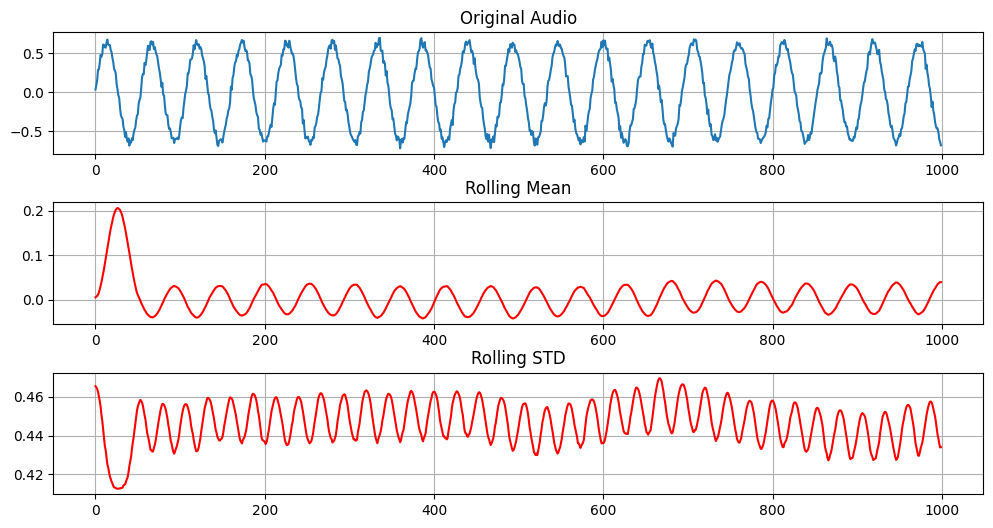

In [14]:
plt.figure(figsize=(12,6))
plt.subplot(311)
plt.plot(audio[:1000])
plt.title("Original Audio")
plt.grid(True)


plt.subplot(312)
plt.plot(rolling_mean[:1000], color='red')
plt.title("Rolling Mean")
plt.grid(True)

plt.subplot(313)
plt.plot(rolling_std[:1000], color='red')
plt.title("Rolling STD")
plt.grid(True)



plt.subplots_adjust(hspace=0.4)
plt.show()

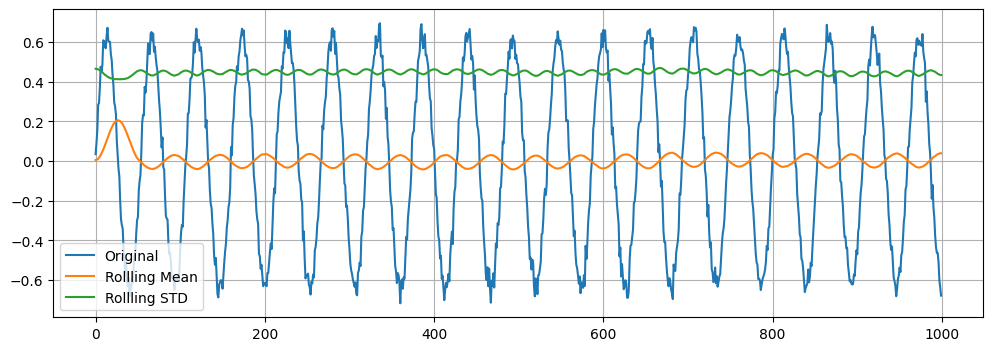

In [16]:
'''audio_norm = audio[:1000]/np.max(np.abs(audio[:1000]))
mean_norm= a[:1000]/np.max(np.abs(a[:1000]))
'''
plt.figure(figsize=(12, 4))
plt.plot(audio[:1000], label='Original')
plt.plot(rolling_mean[:1000], label='Rollling Mean')
plt.plot(rolling_std[:1000], label='Rollling STD')
plt.legend()
plt.grid(True)
plt.show()